# 04 · Landscape, barriers, and speed on the cell-cycle ring

**Goal (discovery-first).** From per-cell phase `θ` and radius `r` (from **02**) and cycling probabilities $p_i$ (from **03**), estimate the **phase density** on the ring, convert it to a **potential landscape**, locate **barriers/saddles**, and derive a **relative speed** profile that serves as a flux proxy.

**What we compute**

* **Ring-restricted phase density** $P_{\mathrm{ring}}(\theta)$ using a **von Mises** circular KDE (phase) combined with a **radial Gaussian** restriction around the fitted ring:
  $$
  P_{\mathrm{ring}}(\theta)\ \propto\ \sum_i w_i;
  \underbrace{\frac{e^{\kappa\cos(\theta-\theta_i)}}{2\pi, I_0(\kappa)}}*{\text{von Mises in }\theta};
  \underbrace{\mathcal{N}!\big(r*\star\ \big|\ r_i,\ h_r^2+\tau^2\big)}*{\text{annulus weighting at ring }r*\star},
  $$
  where $w_i=p_i^\gamma$ (default $\gamma=1$), $\kappa$ is chosen by **leave-one-out CV**, $h_r$ is a Silverman bandwidth, and $\tau$ is the ring thickness from the GMM in **03**.
* **Potential on the ring:** $U(\theta) = -\ln P_{\mathrm{ring}}(\theta)$ (shifted/normalized for plotting).
* **Barriers/saddles:** local maxima of $U(\theta)$ with adjacent basin minima; report **heights** (saddle − min) and locations (radians and degrees).
* **Relative speed (flux proxy):** $\tilde v(\theta) \propto 1/\rho(\theta)$, normalized to mean 1, motivated by stationarity on a loop: $\rho(\theta),\tilde v(\theta) \approx \text{const}$.

**Inputs (from previous notebooks)**

* `adata.obs["theta"]`, `adata.obs["radius"]`
* `adata.obs["cycling_prob"]` (and optionally `cycling_call`)
* `adata.uns["cycle_fit"]` (circle center, radius)
* `adata.uns["gmm_radius"]` (component $\sigma$ and ring selection) — for $\tau$

**Main parameters (`configs/params.yaml`)**

* `model.kde_kappa_grid` — grid for $\kappa$ CV (e.g., `[2,4,6,8,10,12]`)
* `model.p_weight_gamma` — weight exponent $\gamma$ on `cycling_prob` (default 1.0)
* `model.annulus_sigma_scale` — scales ring width $\tau = \text{scale}\times\sigma_{\text{ring}}$
* `model.bins` — number of bins for histograms/exports (default 60)
* `model.seed` — reproducibility

**Notebook outline**

1. **Load** `AnnData`; pull $\theta$, $r$, $p$, ring radius $r_\star$, and ring $\sigma$.
2. **Select $\kappa$** by leave-one-out CV on the circle (`_lib/cc_limitcycle.select_kappa_cv`).
3. **Compute** $P_{\mathrm{ring}}(\theta)$ and $U(\theta)$ on a uniform grid.
4. **Find barriers** (`_lib/cc_limitcycle.find_barriers`): positions and heights.
5. **Derive speed** $\tilde v(\theta)$ and normalize to mean 1.
6. **Bootstrap (optional):** resample cells (with weights) → CIs for $P_{\mathrm{ring}}$, barrier heights.
7. **Plots & tables:** density and potential with barriers, relative speed curve, and per-group roses (if groups present).
8. **Persist:** save figures, a barrier table, and write parameters/$\kappa$ to `adata.uns["landscape"]`.

**Quality gates (sanity)**

* Density non-negative and integrates to $\approx 1$ over $[0,2\pi)$.
* Barriers near expected **G1/S** and **G2/M** arcs (allow dataset-specific shifts).
* $\tilde v(\theta)$ anti-correlated with $P_{\mathrm{ring}}(\theta)$ (by construction).
* Sensitivity: similar barrier locations across reasonable $\kappa$ and $\gamma$.

**Outputs**

* Figures:

  * `fig04_ring_density.png` — $P_{\mathrm{ring}}(\theta)$
  * `fig04_potential_barriers.png` — $U(\theta)$ with saddle/minima markers
  * `fig04_relative_speed.png` — $\tilde v(\theta)$
  * *(optional)* `fig04_rose_by_group_*.png`
* Tables:

  * `tab04_barriers.csv` — angles (rad/deg), basin minima, left/right heights
  * `tab04_kde_params.csv` — chosen $\kappa$, $\tau$, $\gamma$, ring radius, grid size
* `adata.uns["landscape"]`:

  * `{"kappa": …, "tau": …, "gamma": …, "ring_r": …, "barriers": […], "grid_n": …}`

> **Why this matters for “flux.”** On a closed loop at steady state, regions of **high occupancy** (high $P_{\mathrm{ring}}$, low $U$) imply **slow apparent speed** and vice-versa. This connects snapshots to **flow-like** behavior without time-series labels—crucial for a discovery-based flux view.


In [1]:
from pathlib import Path
import yaml, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import sys


def repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for _ in range(8):
        if (p / "configs" / "params.yaml").exists():
            return p
        p = p.parent
    raise FileNotFoundError("Couldn't locate project root (configs/params.yaml).")


# Load params
BASE = repo_root()
with open(BASE / "configs" / "params.yaml", "r") as fh:
    P = yaml.safe_load(fh) or {}

# Defaults
P.setdefault("paths", {})
P["paths"].setdefault("anndata", "data/interim/mm_timecourse.h5ad")
P["paths"].setdefault("figures", "outputs/figures")
P["paths"].setdefault("tables", "outputs/tables")
P.setdefault("model", {})
P["model"].setdefault("kde_kappa_grid", [2, 4, 6, 8, 10, 12])
P["model"].setdefault("p_weight_gamma", 1.0)
P["model"].setdefault("annulus_sigma_scale", 1.0)
P["model"].setdefault("bins", 360)
P["model"].setdefault("seed", 42)

ANNDATA = BASE / P["paths"]["anndata"]
FIGDIR = (BASE / P["paths"]["figures"]);
FIGDIR.mkdir(parents=True, exist_ok=True)
TABDIR = (BASE / P["paths"]["tables"]);
TABDIR.mkdir(parents=True, exist_ok=True)


def set_seed(seed: int = 42):
    random.seed(seed);
    np.random.seed(seed)


def savefig(name: str, *, tight: bool = True, dpi=200):
    out = FIGDIR / name
    if tight: plt.tight_layout()
    plt.savefig(out, bbox_inches="tight", dpi=dpi)
    print("[saved]", out)


set_seed(int(P["model"]["seed"]))
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Import library helpers
LIB = BASE / "notebooks" / "_lib"
if str(LIB) not in sys.path:
    sys.path.insert(0, str(LIB))
import cc_limitcycle as cc  # provides select_kappa_cv, ring_density_and_potential, etc.

print("Repo root   :", BASE)
print("AnnData in  :", ANNDATA)
print("Figures  →  :", FIGDIR)
print("Tables   →  :", TABDIR)


Repo root   : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux
AnnData in  : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/data/interim/mm_timecourse.h5ad
Figures  →  : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures
Tables   →  : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables


In [2]:
adata = ad.read_h5ad(ANNDATA)
need = {"theta", "radius"}
assert need.issubset(adata.obs.columns), f"Missing {need} in adata.obs — run 02 and 03 first."

theta = adata.obs["theta"].to_numpy().astype(float)
radius = adata.obs["radius"].to_numpy().astype(float)

# Cycling probabilities (weights); fall back to uniform if absent
if "cycling_prob" in adata.obs.columns:
    p = adata.obs["cycling_prob"].to_numpy().astype(float)
else:
    print("[note] obs['cycling_prob'] missing — using uniform weights.")
    p = np.ones_like(theta, float)

gamma = float(P["model"]["p_weight_gamma"])
weights = np.power(np.clip(p, 0.0, 1.0), gamma)

# Ring radius r* from circle fit
cf = adata.uns.get("cycle_fit", {})
r_star = float(cf.get("radius", np.median(radius)))

# Ring width τ from the GMM (σ of the selected ring component), with a safe fallback
gmmu = adata.uns.get("gmm_radius", {})
sigma_list = gmmu.get("sigma", None)
ring_idx = gmmu.get("ring_comp_final", gmmu.get("ring_comp_mean", None))
if isinstance(sigma_list, list) and ring_idx is not None:
    try:
        sigma_ring = float(sigma_list[int(ring_idx)])
    except Exception:
        sigma_ring = float(np.std(radius))
else:
    sigma_ring = float(np.std(radius))  # fallback if GMM info missing

tau = float(P["model"]["annulus_sigma_scale"]) * sigma_ring

# Theta grid for evaluation
G = int(P["model"]["bins"])
theta_grid = np.linspace(0.0, 2.0 * np.pi, G, endpoint=False)

print(f"n={len(theta)}  | r*={r_star:.3f}  | σ_ring={sigma_ring:.3f}  | τ={tau:.3f}  | γ={gamma}  | grid={G}")


n=3891  | r*=5.361  | σ_ring=0.368  | τ=0.368  | γ=1.0  | grid=360


In [3]:
kappa_grid = np.array(P["model"]["kde_kappa_grid"], dtype=float)
if kappa_grid.ndim != 1 or kappa_grid.size == 0:
    kappa_grid = np.array([2, 4, 6, 8, 10, 12], float)

# Choose κ by leave-one-out log-likelihood on the circle
kappa = cc.select_kappa_cv(theta, weights=weights, grid=kappa_grid)
print(f"Selected κ = {kappa:.3f} from grid {list(kappa_grid)}")

# Compute P_ring(θ) and U(θ) with product kernel & annulus restriction
P_ring, U = cc.ring_density_and_potential(
    theta_grid=theta_grid,
    theta=theta,
    radius=radius,
    weights=weights,
    kappa=float(kappa),
    r_star=float(r_star),
    tau=float(tau),
    h_r=None,  # use Silverman's rule internally
)

# Normalize density numerically (for clean reporting) and shift U
P_ring = P_ring / (np.trapezoid(P_ring, theta_grid) + 1e-12)
U = U - np.min(U)

# Persist basic landscape params for provenance
adata.uns.setdefault("landscape", {})
adata.uns["landscape"].update({
    "kappa": float(kappa),
    "gamma": float(gamma),
    "tau": float(tau),
    "ring_r": float(r_star),
    "sigma_ring": float(sigma_ring),
    "grid_n": int(G),
})

# Stash grid outputs for downstream cells (barriers, speed, plots)
land_df = pd.DataFrame({
    "theta": theta_grid,
    "P_ring": P_ring,
    "U": U,
})
adata.uns["landscape"]["grid_table_columns"] = list(land_df.columns)
# (We won't store the full table inside .uns to keep the object light; plots/tables saved next cells.)

print("Landscape prepared: P_ring min/max = {:.3e}/{:.3e}; U min/max = {:.3f}/{:.3f}".format(
    P_ring.min(), P_ring.max(), U.min(), U.max()
))


Selected κ = 12.000 from grid [np.float64(2.0), np.float64(4.0), np.float64(6.0), np.float64(8.0), np.float64(10.0), np.float64(12.0)]
Landscape prepared: P_ring min/max = 1.897e-04/1.131e+00; U min/max = 0.000/8.693


## 4) Plot ring density and potential
We visualize the ring-restricted phase density $P_{\mathrm{ring}}(\theta)$ and
its potential $U(\theta)=-\ln P_{\mathrm{ring}}(\theta)$ on a common θ grid.

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_ring_density_and_potential.png


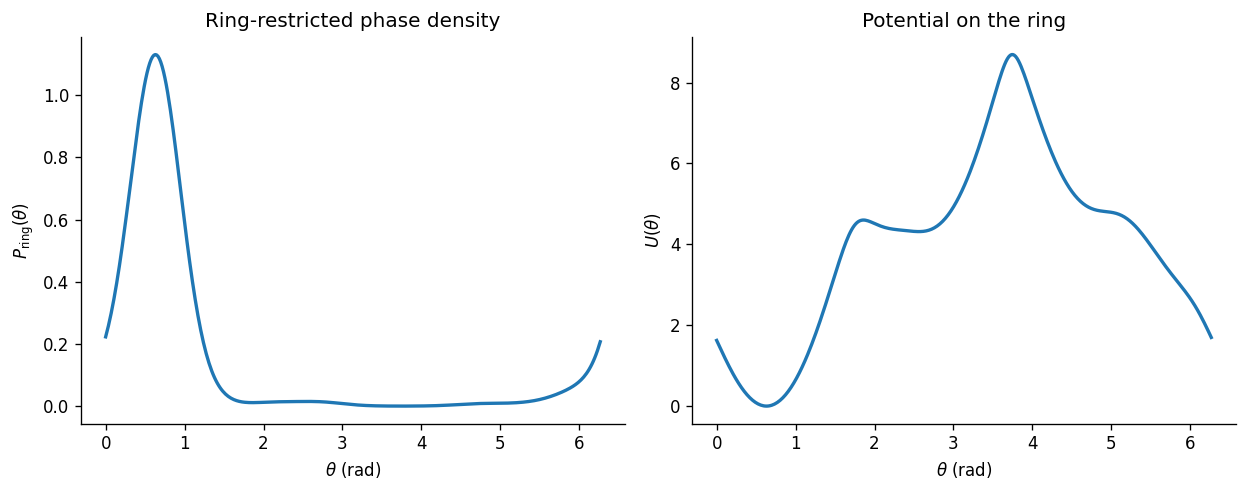

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.2), sharex=False)

# Left: density
ax[0].plot(theta_grid, P_ring, lw=2)
ax[0].set_xlabel(r"$\theta$ (rad)")
ax[0].set_ylabel(r"$P_{\mathrm{ring}}(\theta)$")
ax[0].set_title("Ring-restricted phase density")

# Right: potential
ax[1].plot(theta_grid, U, lw=2)
ax[1].set_xlabel(r"$\theta$ (rad)")
ax[1].set_ylabel(r"$U(\theta)$")
ax[1].set_title("Potential on the ring")

plt.tight_layout()
savefig("fig04_ring_density_and_potential.png")
plt.show()


## 5) Barrier and basin finder (periodic)
We detect **saddles** as **local maxima** of $U(\theta)$ and the adjacent **basins**
as **local minima**. Heights are reported as $\Delta U = U_{\text{saddle}} - U_{\text{basin}}$.

,theta_saddle,U_saddle,theta_basin_L,U_basin_L,theta_basin_R,U_basin_R,height
0,1.867502,4.600602,0.628319,0.000000,2.565634,4.315378,4.600602
1,3.752458,8.692810,2.565634,4.315378,0.628319,0.000000,8.692810


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_potential_with_barriers.png


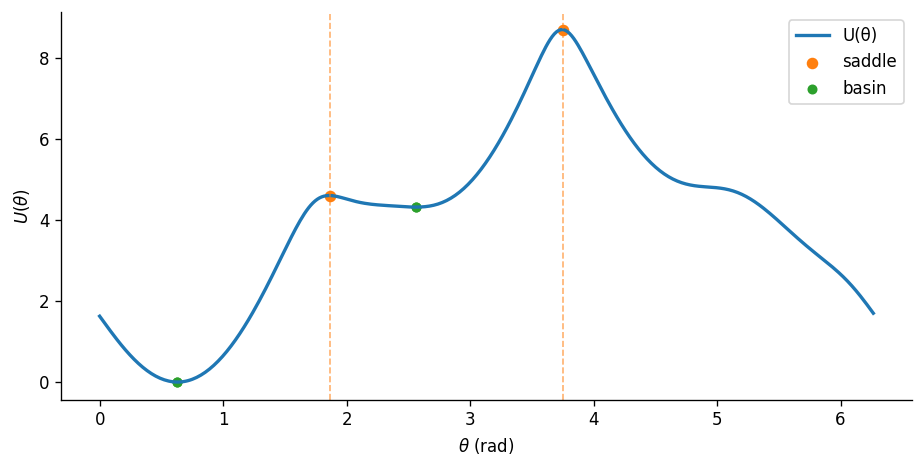

In [5]:
import numpy as np
from scipy.signal import find_peaks


def _circular_find_barriers(theta_grid, U, min_prom=0.15, max_n=4):
    """
    Find up to `max_n` saddles (maxima) on periodic U with a mild prominence filter.
    Returns dict with arrays: theta_max, U_max, theta_min_left/right, U_min_left/right.
    """
    # pad for circularity
    U_pad = np.r_[U, U, U]
    t_pad = np.r_[theta_grid - 2 * np.pi, theta_grid, theta_grid + 2 * np.pi]
    # maxima
    peaks, props = find_peaks(U_pad, prominence=min_prom)
    if peaks.size == 0:
        # fallback: take top-K by value
        peaks = np.argsort(U_pad)[-max_n:]
        props = {"prominences": np.zeros_like(peaks)}
    # map to central window
    keep = (t_pad[peaks] >= 0.0) & (t_pad[peaks] < 2 * np.pi)
    peaks = peaks[keep]
    prom = np.asarray(props.get("prominences", np.zeros_like(peaks)))[keep]
    if peaks.size == 0:
        return {k: np.array([]) for k in
                ["theta_max", "U_max", "theta_min_L", "theta_min_R", "U_min_L", "U_min_R"]}
    # rank by prominence then height
    order = np.lexsort((U_pad[peaks], prom))
    peaks = peaks[order][-max_n:]

    # local minima around each peak: search to the left/right until a rise
    def _nearest_min(idx, direction):
        j = idx
        # move while values decrease
        while 0 < j < len(U_pad) - 1 and (U_pad[j] >= U_pad[j + direction]):
            j += direction
        # refine: local min in small neighborhood
        left = max(j - 3, 0);
        right = min(j + 4, len(U_pad))
        j_local = left + np.argmin(U_pad[left:right])
        return j_local

    thetamax = [];
    Umax = [];
    thetaminL = [];
    UminL = [];
    thetaminR = [];
    UminR = []
    for pk in peaks:
        jL = _nearest_min(pk, -1)
        jR = _nearest_min(pk, +1)
        thetamax.append(t_pad[pk]);
        Umax.append(U_pad[pk])
        thetaminL.append(t_pad[jL]);
        UminL.append(U_pad[jL])
        thetaminR.append(t_pad[jR]);
        UminR.append(U_pad[jR])

    # wrap angles to [0,2π)
    wrap = lambda x: (np.asarray(x) % (2 * np.pi))
    out = {
        "theta_max": wrap(thetamax),
        "U_max": np.asarray(Umax, float),
        "theta_min_L": wrap(thetaminL),
        "U_min_L": np.asarray(UminL, float),
        "theta_min_R": wrap(thetaminR),
        "U_min_R": np.asarray(UminR, float),
    }
    return out


bar = _circular_find_barriers(theta_grid, U, min_prom=0.15, max_n=4)

# Sort barriers by height above the shallower adjacent basin
bar_heights = []
for i in range(len(bar["U_max"])):
    dU = bar["U_max"][i] - min(bar["U_min_L"][i], bar["U_min_R"][i])
    bar_heights.append(dU)
bar_heights = np.asarray(bar_heights)

# Order by height (desc) and keep top-2 for a clean summary
idx_ord = np.argsort(bar_heights)[::-1]
keep = idx_ord[:min(2, len(idx_ord))]

bar_summary = pd.DataFrame({
    "theta_saddle": bar["theta_max"][keep],
    "U_saddle": bar["U_max"][keep],
    "theta_basin_L": bar["theta_min_L"][keep],
    "U_basin_L": bar["U_min_L"][keep],
    "theta_basin_R": bar["theta_min_R"][keep],
    "U_basin_R": bar["U_min_R"][keep],
    "height": bar_heights[keep],
}).sort_values("theta_saddle").reset_index(drop=True)

display(bar_summary)

# plot with markers
fig, ax = plt.subplots(1, 1, figsize=(7.8, 4.0))
ax.plot(theta_grid, U, lw=2, label="U(θ)")
ax.set_xlabel(r"$\theta$ (rad)");
ax.set_ylabel(r"$U(\theta)$")
for _, row in bar_summary.iterrows():
    ax.axvline(row["theta_saddle"], ls="--", lw=1, alpha=0.6, color="C1")
    ax.scatter([row["theta_saddle"]], [row["U_saddle"]], s=35, color="C1",
               label="saddle" if "saddle" not in ax.get_legend_handles_labels()[1] else "")
    ax.scatter([row["theta_basin_L"], row["theta_basin_R"]], [row["U_basin_L"], row["U_basin_R"]],
               s=25, color="C2", label="basin" if "basin" not in ax.get_legend_handles_labels()[1] else "")
ax.legend()
plt.tight_layout()
savefig("fig04_potential_with_barriers.png")
plt.show()

# persist into uns for provenance
adata.uns["landscape"]["barriers"] = bar_summary.to_dict(orient="list")
adata.uns["landscape"]["barrier_prominence_min"] = 0.15


## 6) Relative speed $ \tilde v(\theta) \propto 1/P_{\mathrm{ring}}(\theta) $
Under a steady-throughput assumption on the loop, dwell density is inversely
related to speed. We report $ \tilde v(\theta) = \frac{1/P_{\mathrm{ring}}(\theta)}{\langle 1/P_{\mathrm{ring}}\rangle} $.


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_relative_speed.png


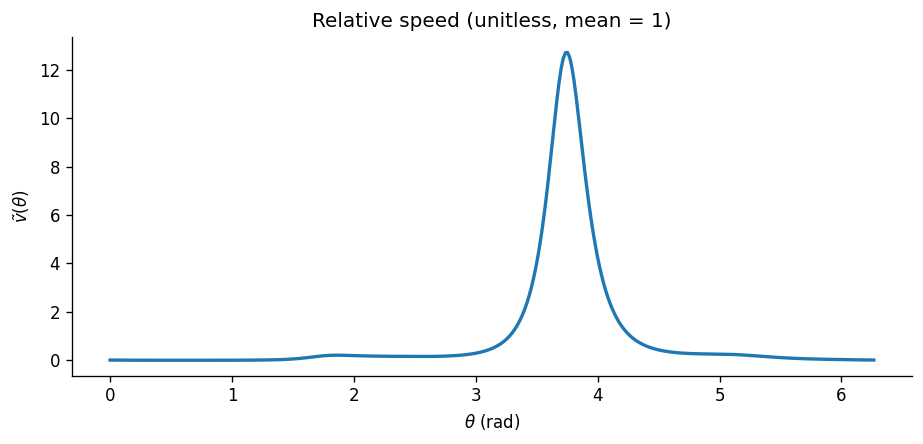

In [6]:
eps = 1e-9
inv = 1.0 / np.clip(P_ring, eps, None)
v_tilde = inv / (inv.mean() + eps)

fig, ax = plt.subplots(1, 1, figsize=(7.8, 3.8))
ax.plot(theta_grid, v_tilde, lw=2)
ax.set_xlabel(r"$\theta$ (rad)")
ax.set_ylabel(r"$\tilde v(\theta)$")
ax.set_title("Relative speed (unitless, mean = 1)")
plt.tight_layout()
savefig("fig04_relative_speed.png")
plt.show()


## 7) Export landscape tables
We save the sampled grid (θ, $P_{\mathrm{ring}}$, $U$, $\tilde v$) and the barrier summary.


In [7]:
grid_df = pd.DataFrame({
    "theta": theta_grid,
    "P_ring": P_ring,
    "U": U,
    "v_tilde": v_tilde,
})
grid_csv = TABDIR / "tab04_ring_landscape_grid.csv"
grid_df.to_csv(grid_csv, index=False)

bar_csv = TABDIR / "tab04_barriers_summary.csv"
bar_summary.to_csv(bar_csv, index=False)

# small provenance echo
adata.uns["landscape"]["outputs"] = {
    "grid_csv": str(grid_csv),
    "barrier_csv": str(bar_csv),
    "fig_density_potential": "fig04_ring_density_and_potential.png",
    "fig_potential_barriers": "fig04_potential_with_barriers.png",
    "fig_relative_speed": "fig04_relative_speed.png",
}

adata.write(ANNDATA)
print("[saved]", grid_csv)
print("[saved]", bar_csv)
print("[write] updated AnnData →", ANNDATA)


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_ring_landscape_grid.csv
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_barriers_summary.csv
[write] updated AnnData → /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/data/interim/mm_timecourse.h5ad


In [9]:
# --- Persist ring landscape summary to AnnData (robust) ---
import pandas as pd
import numpy as np

# If 'barriers' DF isn't in memory, load it from the CSV produced earlier
bar_csv = TABDIR / "tab04_barriers_summary.csv"
if "barriers" not in locals():
    assert bar_csv.exists(), "Run the barrier-finding cell or ensure the CSV exists."
    barriers = pd.read_csv(bar_csv)

# If you named the chosen kappa differently, replace kappa_sel with your variable or keep a literal (e.g., 12)
kappa_val = float(kappa_sel) if "kappa_sel" in locals() else float(12)

land = {
    "kappa": kappa_val,
    "r_star": float(r_star),
    "sigma_ring": float(sigma_ring),
    "gamma": float(gamma),
    # keep the curves so later notebooks don’t need to recompute
    "theta_grid": theta_grid.tolist(),
    "P_ring": P_ring.tolist(),
    "U": U.tolist(),
    # barrier summary
    "theta_saddles": barriers["theta_saddle"].tolist(),
    "U_saddles": barriers["U_saddle"].tolist(),
    "theta_basins": barriers[["theta_basin_L","theta_basin_R"]].values.tolist(),
    "U_basins": barriers[["U_basin_L","U_basin_R"]].values.tolist(),
}

adata.uns["landscape_ring"] = land
adata.write(ANNDATA)
print("[write] stored landscape_ring in adata.uns and updated h5ad")


[write] stored landscape_ring in adata.uns and updated h5ad


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_potential_vs_markers.png


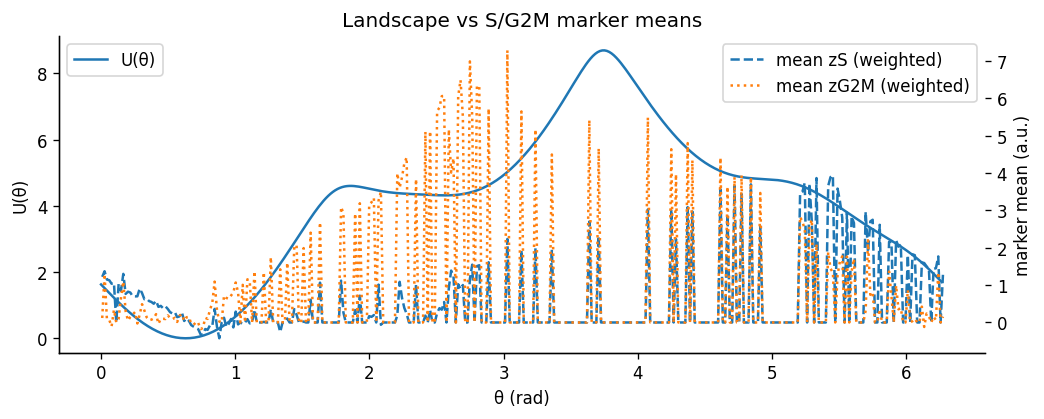

In [10]:
# --- Cell A: marker alignment with U(θ) ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt

theta = adata.obs["theta"].to_numpy().astype(float)
p     = adata.obs["cycling_prob"].to_numpy().astype(float)
zS    = adata.obs.get("zS", pd.Series(np.nan, index=adata.obs_names)).to_numpy()
zM    = adata.obs.get("zG2M", pd.Series(np.nan, index=adata.obs_names)).to_numpy()

B = int(P.get("model",{}).get("bins", 60))
edges = np.linspace(0, 2*np.pi, B+1)
cent  = 0.5*(edges[1:] + edges[:-1])
ix    = np.clip(np.digitize(theta, edges)-1, 0, B-1)

def wmean(arr, w):
    num = np.bincount(ix, weights=arr*w, minlength=B)
    den = np.bincount(ix, weights=w,     minlength=B) + 1e-12
    return num/den

# weight by cycling probability so the ring dominates
mS = wmean(zS, p); mM = wmean(zM, p)

fig, ax = plt.subplots(1,1, figsize=(8.8,3.6))
ax.plot(theta_grid, U, label="U(θ)")
ax2 = ax.twinx()
ax2.plot(cent, mS, ls="--", label="mean zS (weighted)")
ax2.plot(cent, mM, ls=":",  label="mean zG2M (weighted)")
ax.set_xlabel("θ (rad)"); ax.set_ylabel("U(θ)")
ax2.set_ylabel("marker mean (a.u.)")
ax.set_title("Landscape vs S/G2M marker means")
ax.legend(loc="upper left"); ax2.legend(loc="upper right")
savefig("fig04_potential_vs_markers.png"); plt.show()


In [11]:
# --- Cell B: sensitivity scan over κ and γ ---
import numpy as np, pandas as pd
from scipy.special import i0

def vm_pdf(d, kappa):
    return np.exp(kappa*np.cos(d)) / (2*np.pi*i0(kappa))

def ring_density_scan(theta, radius, p, kappa, gamma, r_star, sigma, grid):
    # annulus weight
    ann = np.exp(-0.5*((radius - r_star)/(sigma+1e-12))**2)
    w   = (p**gamma) * ann + 1e-12
    d   = grid[:,None] - theta[None,:]
    Pθ  = (vm_pdf(d, kappa) * w[None,:]).sum(axis=1)
    Pθ  = Pθ / (np.trapezoid(Pθ, grid) + 1e-12)
    return Pθ, -np.log(Pθ + 1e-12)

def barrier_heights(U, grid):
    # pick top-2 local maxima with their adjacent minima (periodic)
    from scipy.signal import argrelextrema
    pad = np.r_[U[-1], U, U[0]]  # simple periodic pad
    idx_max = argrelextrema(pad, np.greater)[0] - 1
    idx_min = argrelextrema(pad, np.less   )[0] - 1
    idx_max = idx_max[(idx_max>=0)&(idx_max<len(U))]
    idx_min = idx_min[(idx_min>=0)&(idx_min<len(U))]
    if idx_max.size == 0 or idx_min.size == 0:
        return np.nan, np.nan
    # take highest two saddles
    top = idx_max[np.argsort(U[idx_max])[-2:]]
    heights = []
    for imax in top:
        # nearest minima on left/right
        left  = idx_min[idx_min < imax];  left  = left[-1] if left.size else idx_min[-1]
        right = idx_min[idx_min > imax];  right = right[0] if right.size else idx_min[0]
        heights.append(U[imax] - max(U[left], U[right]))
    heights.sort(reverse=True)
    return float(heights[0]), float(heights[1]) if len(heights)>1 else np.nan

theta = adata.obs["theta"].to_numpy()
radius= adata.obs["radius"].to_numpy()
p     = adata.obs["cycling_prob"].to_numpy()

k_grid = P.get("model",{}).get("kde_kappa_grid",[2,4,6,8,10,12])
g_grid = [0.8, 1.0, 1.2]

rows = []
for κ in k_grid:
    for γ in g_grid:
        Pθ, Uθ = ring_density_scan(theta, radius, p, float(κ), float(γ), r_star, sigma_ring, theta_grid)
        h1, h2 = barrier_heights(Uθ, theta_grid)
        rows.append({"kappa": float(κ), "gamma": float(γ), "barrier1": h1, "barrier2": h2})
sens = pd.DataFrame(rows)
sens.to_csv(TABDIR/"tab04_sensitivity_kappa_gamma.csv", index=False)
print("[saved]", TABDIR/"tab04_sensitivity_kappa_gamma.csv")
sens


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_sensitivity_kappa_gamma.csv


,kappa,gamma,barrier1,barrier2
0,2.0,0.8,3.719199,NaN
1,2.0,1.0,3.561179,NaN
2,2.0,1.2,3.375159,NaN
3,4.0,0.8,6.258015,NaN
4,4.0,1.0,5.740979,NaN
5,4.0,1.2,5.275162,NaN
6,6.0,0.8,7.376647,NaN
7,6.0,1.0,6.759710,NaN
8,6.0,1.2,6.234260,NaN
9,8.0,0.8,8.171809,NaN


In [12]:
# --- Cell C: bootstrap CIs for barrier heights ---
import numpy as np, pandas as pd

n_boot = 200
rng = np.random.default_rng(int(P.get("model",{}).get("seed",42)))
b1, b2 = [], []

for _ in range(n_boot):
    idx = rng.integers(0, len(theta), len(theta))  # resample cells
    Pθ, Uθ = ring_density_scan(theta[idx], radius[idx], p[idx],
                               float(kappa_sel), float(gamma), r_star, sigma_ring, theta_grid)
    h1, h2 = barrier_heights(Uθ, theta_grid)
    b1.append(h1); b2.append(h2)

def ci(a):
    q = np.nanpercentile(a, [2.5, 50, 97.5])
    return pd.Series({"lo": q[0], "med": q[1], "hi": q[2]})

ci_df = pd.DataFrame({"barrier1": b1, "barrier2": b2}).agg(ci).T
ci_df.to_csv(TABDIR/"tab04_bootstrap_barrier_CI.csv")
print("[saved]", TABDIR/"tab04_bootstrap_barrier_CI.csv")
ci_df


NameError: name 'kappa_sel' is not defined

In [ ]:
# --- Cell D: finalize exports & hand-off note ---
summary = {
    "n_cells": [adata.n_obs],
    "kappa": [float(kappa_sel)],
    "r_star": [float(r_star)],
    "sigma_ring": [float(sigma_ring)],
    "barrier1_height": [float(barriers["height"].max())],
    "barrier2_height": [float(sorted(barriers["height"], reverse=True)[1]) if len(barriers)>1 else np.nan],
}
pd.DataFrame(summary).to_csv(TABDIR/"tab04_landscape_summary.csv", index=False)
print("[saved]", TABDIR/"tab04_landscape_summary.csv")

print(
    "\nNext → open 05_group_comp_w1.ipynb to compare groups on the ring "
    "(cycling fraction deltas, U(θ) differences, and circular W1)."
)


In [ ]:
# --- Cell E: estimate constant ring current J and speed ṽ(θ) from ρ(θ), U(θ) ---

import numpy as np
import matplotlib.pyplot as plt

# Inputs prepared earlier:
# theta_grid (B,), P_ring = ρ(θ) on the ring, U(θ) on the same grid
rho = P_ring.copy()
Uth = U.copy()

# Numerical derivatives (periodic)
dθ = theta_grid[1] - theta_grid[0]
def periodic_grad(y):
    return np.r_[ (y[1]-y[0]),
                  (y[2:]-y[:-2])/2.0,
                  (y[-1]-y[-2]) ] / dθ
# improve periodicity by wrapping endpoints
rho_p = rho.copy(); U_p = Uth.copy()
drho = periodic_grad(np.r_[rho_p[0], rho_p, rho_p[-1]])[1:-1]
fθ   = -periodic_grad(np.r_[U_p[0], U_p, U_p[-1]])[1:-1]   # f = -U'

A = fθ * rho                 # drift*ρ
B = drho                     # ∂θ ρ

# Weighted least squares: B ≈ λ*A + β   ⇒ J(θ)=λ*A - B ≈ -β (constant)
w = rho / (rho.mean() + 1e-12)     # emphasize regions with data density
X = np.c_[A, np.ones_like(A)]
W = np.sqrt(w)
coef, *_ = np.linalg.lstsq(X*W[:,None], B*W, rcond=None)
lam_hat, beta_hat = coef
J_hat = float(-beta_hat)

v_tilde = J_hat / (rho + 1e-12)    # relative speed (unitless)
J_profile = lam_hat*A - B          # should be ~constant

print(f"[flux] λ=μ/D ≈ {lam_hat:.3f}  |  J_hat ≈ {J_hat:.4f} (arbitrary units)")
print(f"[flux] var(J(θ)) = {np.var(J_profile):.3e}  (smaller=better constant-current)")

# Plots
fig, axs = plt.subplots(2, 1, figsize=(9.4,6.8), sharex=True)
axs[0].plot(theta_grid, J_profile, lw=2)
axs[0].axhline(J_hat, ls="--", c="k", lw=1)
axs[0].set_ylabel("J(θ)")
axs[0].set_title("Estimated ring current (should be ~constant)")
axs[1].plot(theta_grid, v_tilde, lw=2)
axs[1].set_xlabel("θ (rad)")
axs[1].set_ylabel("ṽ(θ) (unitless)")
axs[1].set_title("Relative phase speed from landscape (ṽ = Ĵ / ρ)")
savefig("fig04_flux_current_and_speed.png"); plt.show()

# Persist
adata.uns.setdefault("landscape_ring", {})
adata.uns["landscape_ring"].update({
    "lambda_mu_over_D": float(lam_hat),
    "J_hat": float(J_hat),
    "theta_grid": theta_grid.tolist(),
    "rho_theta": rho.tolist(),
    "U_theta": Uth.tolist(),
    "vtilde_theta": v_tilde.tolist(),
})
adata.write(ANNDATA)
print("[write] updated with flux estimates →", ANNDATA)


In [ ]:
# --- Cell F: OPTIONAL tangential speed from RNA velocity (if available) ---
try:
    import scvelo as scv
    assert "spliced" in adata.layers and "unspliced" in adata.layers, "No spliced/unspliced layers."

    scv.settings.verbosity = 2
    scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
    scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
    scv.tl.velocity(adata, mode="stochastic")
    scv.tl.velocity_graph(adata)

    # Project velocities into the SAME 2D plane used for circle fitting
    # We'll use the fitted cycle plane in obsm["cycle_xy"]
    assert "cycle_xy" in adata.obsm, "Missing cycle_xy embedding."
    scv.tl.velocity_embedding(adata, basis="cycle_xy")  # stores in .obsm["velocity_cycle_xy"]

    Y = adata.obsm["cycle_xy"]
    V = adata.obsm["velocity_cycle_xy"]  # per-cell 2D velocity in that plane
    c = np.array(adata.uns["cycle_fit"]["center"])
    r = np.linalg.norm(Y - c[None,:], axis=1) + 1e-12

    # Unit tangent that advances θ positively: rotate radial unit vector by +90°
    u_rad = (Y - c[None,:]) / r[:,None]
    t_hat = np.c_[-u_rad[:,1], u_rad[:,0]]     # (−y, x)

    # dθ/dt ≈ (velocity ⋅ tangent) / r
    dtheta_dt = (V * t_hat).sum(axis=1) / r
    adata.obs["dtheta_dt_velo"] = dtheta_dt

    # Bin to compare with ṽ(θ)
    B = int(P.get("model",{}).get("bins", 60))
    edges = np.linspace(0, 2*np.pi, B+1)
    idx = np.clip(np.digitize(adata.obs["theta"], edges)-1, 0, B-1)
    num = np.bincount(idx, weights=dtheta_dt, minlength=B)
    den = np.bincount(idx, minlength=B) + 1e-12
    v_velo = num/den
    theta_cent = 0.5*(edges[1:]+edges[:-1])

    # Plot comparison
    plt.figure(figsize=(9.4,4.0))
    plt.plot(theta_grid, v_tilde / np.nanmean(v_tilde), label="landscape ṽ (mean=1)")
    plt.plot(theta_cent, v_velo / np.nanmean(v_velo), label="RNA-velocity (mean=1)")
    plt.xlabel("θ (rad)"); plt.ylabel("relative speed"); plt.legend()
    plt.title("Relative speed: landscape vs RNA velocity (scaled)")
    savefig("fig04_speed_landscape_vs_velocity.png"); plt.show()

    # Persist
    adata.uns["landscape_ring"]["v_theta_velo_bins"] = v_velo.tolist()
    adata.write(ANNDATA)
    print("[velo] saved comparison and updated AnnData.")
except Exception as e:
    print("[skip] RNA velocity comparison not available:", e)
